# Language-Agnostic Speaker Recognition
### wav2vec 2.0 (XLSR-53) + AAM-Softmax
**Dataset:** LibriSpeech only (`openslr/librispeech_asr`)
| Split | Role | Speakers |
|---|---|---|
| train.100 | Training | 251 |
| validation | Val during training | 40 |
| test | Final evaluation | 40 |

---
⚠️ **Run Cell 1 → Restart Session → Run Cell 2 onwards**

In [1]:
# ── CELL 1: Install — then RESTART SESSION ────────────────────
# Kaggle/Linux+CUDA used cu118; on macOS use PyPI wheels (no CUDA builds on that index).
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets scikit-learn scipy torchcodec matplotlib
print('✅ Done. Restart Session now, then run from Cell 2.')

✅ Done. Restart Session now, then run from Cell 2.


In [2]:
# ── CELL 2: Imports ───────────────────────────────────────────
import os, random
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import Wav2Vec2Model
from datasets import load_dataset
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.stats import norm as scipy_norm
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Device  :', device)
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.version.cuda)
if device.type == 'cuda':
    print('GPU     :', torch.cuda.get_device_name(0))
elif device.type == 'mps':
    print('GPU     : Apple MPS (Metal)')

Device  : mps
PyTorch : 2.11.0
CUDA    : None
GPU     : Apple MPS (Metal)


In [3]:
# ── CELL 3: Config ────────────────────────────────────────────
@dataclass
class Config:
    # Model
    wav2vec_model: str          = 'facebook/wav2vec2-large-xlsr-53'
    unfreeze_last_n_layers: int = 4
    embedding_dim: int          = 256

    # Audio
    sample_rate: int            = 16000
    max_duration_sec: float     = 3.0

    # LibriSpeech splits
    dataset: str                = 'openslr/librispeech_asr'
    subset: str                 = 'clean'
    max_train_samples: int      = 12000     # ~108 speakers, 750 batches/epoch
    min_utts_per_speaker: int   = 5
    trials_per_speaker: int     = 20

    # Training
    num_speakers: int           = 251       # overridden at runtime
    batch_size: int             = 16        # small batch → more steps → better EER
    lr: float                   = 1e-4      # correct for batch 16
    weight_decay: float         = 1e-4
    num_epochs: int             = 10
    warmup_epochs: int          = 1
    grad_clip: float            = 5.0
    num_workers: int            = 0         # must stay 0 on macOS notebooks

    # AAM-Softmax
    aam_margin: float           = 0.2
    aam_scale: float            = 30.0

    checkpoint_dir: str         = 'checkpoints'
    seed: int                   = 42
    log_every: int              = 50

    @property
    def max_audio_len(self): return int(self.max_duration_sec * self.sample_rate)

cfg = Config()
os.makedirs(cfg.checkpoint_dir, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        torch.mps.manual_seed(s)

def crop_or_pad(wav, n):
    T = wav.shape[0]
    if T >= n:
        s = random.randint(0, T - n)
        return wav[s: s + n]
    return F.pad(wav, (0, n - T))

def to_tensor(arr, sr):
    w = torch.tensor(arr, dtype=torch.float32)
    if sr != cfg.sample_rate:
        w = torchaudio.functional.resample(w, sr, cfg.sample_rate)
    return w

set_seed(cfg.seed)
print('Config ready')
print(f'  max_duration_sec  : {cfg.max_duration_sec}s  ({cfg.max_audio_len:,} samples/clip)')
print(f'  max_train_samples : {cfg.max_train_samples:,}')
print(f'  batch_size        : {cfg.batch_size}')
print(f'  lr (peak)         : {cfg.lr}')
print(f'  num_epochs        : {cfg.num_epochs}')
print(f'  batches/epoch     : {cfg.max_train_samples // cfg.batch_size}')
print(f'  total steps       : {(cfg.max_train_samples // cfg.batch_size) * cfg.num_epochs:,}')

Config ready
  max_duration_sec  : 3.0s  (48,000 samples/clip)
  max_train_samples : 12,000
  batch_size        : 16
  lr (peak)         : 0.0001
  num_epochs        : 10
  batches/epoch     : 750
  total steps       : 7,500


In [4]:
# ── CELL 4: Stream a LibriSpeech split into memory ────────────
import io
import time
from datasets import Audio
from datasets.download.download_config import DownloadConfig
from datasets.download.download_manager import DownloadMode
from datasets.utils.file_utils import xopen


def _audio_item_to_arr_sr(audio) -> Tuple[np.ndarray, int]:
    """Decode LibriSpeech FLAC without torchcodec (datasets 4.x defaults to torchcodec for Audio(decode=True))."""
    if audio is None:
        raise ValueError('missing audio')
    if isinstance(audio, dict) and audio.get('array') is not None:
        return np.array(audio['array'], dtype=np.float32), int(audio['sampling_rate'])
    if not isinstance(audio, dict):
        audio = {'path': getattr(audio, 'path', None), 'bytes': getattr(audio, 'bytes', None)}
    b, p = audio.get('bytes'), audio.get('path')
    if b is not None:
        wav, sr = torchaudio.load(io.BytesIO(b))
    elif p is not None:
        with xopen(p, 'rb', download_config=DownloadConfig()) as f:
            wav, sr = torchaudio.load(io.BytesIO(f.read()))
    else:
        raise ValueError(f'cannot decode audio field: {audio}')
    arr = wav.mean(dim=0).numpy().astype(np.float32)
    return arr, int(sr)


def _open_librispeech_split(split_name: str):
    """Prefer Hub streaming; on Broken pipe (common in notebooks), use disk-cached Arrow dataset."""
    last_err = None
    for attempt in range(3):
        try:
            ds = load_dataset(cfg.dataset, cfg.subset, split=split_name, streaming=True)
            return ds.cast_column('audio', Audio(decode=False)), 'streaming'
        except (RuntimeError, OSError) as e:
            last_err = e
            msg = str(e).lower()
            if 'broken pipe' in msg or 'errno 32' in msg or 'connection reset' in msg:
                time.sleep(1.5 * (attempt + 1))
                continue
            raise
    print(f'  Streaming unavailable ({type(last_err).__name__}: {last_err})')
    print('  Falling back to streaming=False (downloads/caches split on disk; first run is slower, more stable).')
    ds = load_dataset(
        cfg.dataset,
        cfg.subset,
        split=split_name,
        streaming=False,
        download_mode=DownloadMode.REUSE_DATASET_IF_EXISTS,
    )
    return ds.cast_column('audio', Audio(decode=False)), 'cached'


def stream_split(split_name: str, max_samples: int = None) -> Dict[str, List]:
    """
    Streams a LibriSpeech split, groups audio arrays by speaker_id.
    Returns: {speaker_id: [(arr, sr), ...]}
    """
    print(f'Loading {split_name} ...')
    raw, how = _open_librispeech_split(split_name)
    print(f'  mode: {how}')
    spk_items: Dict[str, List] = {}
    for i, item in enumerate(raw):
        if max_samples and i >= max_samples:
            break
        spk = str(item['speaker_id'])
        arr, sr = _audio_item_to_arr_sr(item['audio'])
        spk_items.setdefault(spk, []).append((arr, sr))
        if (i + 1) % 2000 == 0:
            print(f'  {i+1} loaded ...')
    print(f'  Done: {len(spk_items)} speakers, {sum(len(v) for v in spk_items.values())} utterances')
    return spk_items

print('stream_split() defined')

stream_split() defined


In [5]:
# ── CELL 5: Dataset classes ───────────────────────────────────
class TrainDataset(Dataset):
    """Classification dataset for AAM-Softmax training."""
    def __init__(self, spk_items: Dict):
        spk_items = {k: v for k, v in spk_items.items()
                     if len(v) >= cfg.min_utts_per_speaker}
        self.spk2idx = {s: i for i, s in enumerate(sorted(spk_items))}
        self.samples = [(arr, sr, self.spk2idx[s])
                        for s, items in spk_items.items() for arr, sr in items]
        cfg.num_speakers = len(self.spk2idx)
        print(f'TrainDataset: {cfg.num_speakers} speakers, {len(self.samples)} utterances')

    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        arr, sr, idx = self.samples[i]
        return {'wav':   crop_or_pad(to_tensor(arr, sr), cfg.max_audio_len),
                'label': torch.tensor(idx, dtype=torch.long)}


class VerificationDataset(Dataset):
    """Trial-pair dataset for EER evaluation."""
    def __init__(self, spk_items: Dict, split_name: str):
        self.spk_items = {k: v for k, v in spk_items.items() if len(v) >= 2}
        self.trials    = self._build_trials()
        print(f'VerifDataset [{split_name}]: '
              f'{len(self.spk_items)} speakers, {len(self.trials)} trials')

    def _build_trials(self) -> List[Tuple]:
        trials, spks = [], list(self.spk_items.keys())
        n = cfg.trials_per_speaker
        for spk in spks:
            utts = self.spk_items[spk]
            for _ in range(n // 2):                          # genuine
                a, b = random.sample(utts, 2)
                trials.append((a, b, 1))
            for _ in range(n // 2):                          # impostor
                other = random.choice([s for s in spks if s != spk])
                trials.append((random.choice(utts),
                               random.choice(self.spk_items[other]), 0))
        random.shuffle(trials)
        return trials

    def __len__(self): return len(self.trials)
    def __getitem__(self, i):
        (a, a_sr), (b, b_sr), lbl = self.trials[i]
        return {'wav1':  crop_or_pad(to_tensor(a, a_sr), cfg.max_audio_len),
                'wav2':  crop_or_pad(to_tensor(b, b_sr), cfg.max_audio_len),
                'label': torch.tensor(lbl, dtype=torch.long)}

print('Dataset classes defined')

Dataset classes defined


In [6]:
# ── CELL 6: Model ─────────────────────────────────────────────
class AttentivePool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(d, 128), nn.Tanh(), nn.Linear(128, 1))
    def forward(self, x):                                    # [B, T, D]
        w = torch.softmax(self.attn(x), dim=1)              # [B, T, 1]
        m = (w * x).sum(1)                                  # [B, D]
        s = (w * (x - m.unsqueeze(1))**2).sum(1).clamp(1e-9).sqrt()
        return torch.cat([m, s], -1)                         # [B, 2D]


class SpeakerEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.bb = Wav2Vec2Model.from_pretrained(cfg.wav2vec_model)
        for p in self.bb.parameters(): p.requires_grad = False
        for layer in self.bb.encoder.layers[-cfg.unfreeze_last_n_layers:]:
            for p in layer.parameters(): p.requires_grad = True
        D = self.bb.config.hidden_size                       # 1024
        self.pool = AttentivePool(D)
        self.proj = nn.Sequential(
            nn.Linear(D*2, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, cfg.embedding_dim))
    def forward(self, wav):                                  # [B, T]
        h = self.bb(wav).last_hidden_state                   # [B, T', D]
        return F.normalize(self.proj(self.pool(h)), dim=-1)  # [B, emb_dim]


class AAMSoftmax(nn.Module):
    def __init__(self, d, n, m=0.2, s=30.0):
        super().__init__()
        self.s = s
        self.W = nn.Parameter(torch.empty(n, d))
        nn.init.xavier_uniform_(self.W)
        mt = torch.tensor(m)
        self.register_buffer('cos_m', torch.cos(mt))
        self.register_buffer('sin_m', torch.sin(mt))
        self.register_buffer('th',    torch.cos(torch.pi - mt))
        self.register_buffer('mm',    torch.sin(torch.pi - mt) * m)
    def forward(self, e, y):
        c  = e @ F.normalize(self.W, dim=-1).T
        sx = (1 - c**2).clamp(0, 1).sqrt()
        p  = torch.where(c > self.th, c*self.cos_m - sx*self.sin_m, c - self.mm)
        oh = torch.zeros_like(c).scatter_(1, y.unsqueeze(1), 1.)
        return F.cross_entropy((oh*p + (1-oh)*c) * self.s, y)


class SpeakerModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = SpeakerEncoder(cfg)
        self.loss_fn  = AAMSoftmax(cfg.embedding_dim, cfg.num_speakers,
                                   cfg.aam_margin, cfg.aam_scale)
    def forward(self, wav, labels=None):
        e = self.encoder(wav)
        return (self.loss_fn(e, labels), e) if labels is not None else e

print('Model defined')

Model defined


In [7]:
# ── CELL 7: Metrics ───────────────────────────────────────────
def compute_eer(labels, scores):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    return float(brentq(lambda x: x - interp1d(fpr, fnr)(x), 0, 1)) * 100

def compute_mindcf(labels, scores, p=0.01):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    dcf = (1 - tpr) * p + fpr * (1 - p)
    return float(np.min(dcf)) / min(p, 1 - p)

@torch.no_grad()
def get_scores_and_labels(encoder, loader):
    encoder.eval()
    scores, labels = [], []
    for b in loader:
        s = F.cosine_similarity(encoder(b['wav1'].to(device)),
                                encoder(b['wav2'].to(device))).cpu().numpy()
        scores.append(s)
        labels.append(b['label'].numpy())
    return np.concatenate(scores), np.concatenate(labels)

@torch.no_grad()
def evaluate(encoder, loader):
    sc, lb = get_scores_and_labels(encoder, loader)
    return {'eer': compute_eer(lb, sc), 'mindcf': compute_mindcf(lb, sc)}

@torch.no_grad()
def extract_embeddings(encoder, spk_items, max_speakers=20, max_utts=8):
    """Extract per-utterance embeddings for a subset of speakers."""
    encoder.eval()
    embs, spk_ids = [], []
    for spk in sorted(spk_items.keys())[:max_speakers]:
        for arr, sr in spk_items[spk][:max_utts]:
            wav = crop_or_pad(to_tensor(arr, sr), cfg.max_audio_len).unsqueeze(0).to(device)
            embs.append(encoder(wav).cpu().numpy()[0])
            spk_ids.append(spk)
    return np.array(embs), spk_ids

@torch.no_grad()
def mean_speaker_embedding(encoder, items, max_utts=5):
    encoder.eval()
    embs = []
    for arr, sr in items[:max_utts]:
        wav = crop_or_pad(to_tensor(arr, sr), cfg.max_audio_len).unsqueeze(0).to(device)
        embs.append(encoder(wav).cpu())
    return torch.stack(embs).mean(0)

print('Metrics defined')

Metrics defined


In [8]:
# ── CELL 8: Load all splits ───────────────────────────────────
train_items = stream_split('train.100', max_samples=cfg.max_train_samples)
val_items   = stream_split('validation')
test_items  = stream_split('test')

train_ds = TrainDataset(train_items)
val_ds   = VerificationDataset(val_items,  'validation')
test_ds  = VerificationDataset(test_items, 'test')

_num_workers = 0
_pin_memory  = device.type == 'cuda'   # MPS does not support pin_memory

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=_num_workers, pin_memory=_pin_memory, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=16, num_workers=_num_workers, pin_memory=_pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=16, num_workers=_num_workers, pin_memory=_pin_memory)

print(f'\nTrain: {len(train_loader)} batches')
print(f'Val  : {len(val_loader)} batches')
print(f'Test : {len(test_loader)} batches')

Loading train.100 ...


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

  mode: streaming
  2000 loaded ...
  4000 loaded ...
  6000 loaded ...
  8000 loaded ...
  10000 loaded ...
  12000 loaded ...
  Done: 108 speakers, 12000 utterances
Loading validation ...


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

  mode: streaming
  2000 loaded ...
  Done: 40 speakers, 2703 utterances
Loading test ...


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

  mode: streaming
  2000 loaded ...
  Done: 40 speakers, 2620 utterances
TrainDataset: 108 speakers, 12000 utterances
VerifDataset [validation]: 40 speakers, 800 trials
VerifDataset [test]: 40 speakers, 800 trials

Train: 750 batches
Val  : 50 batches
Test : 50 batches


In [9]:
# ── CELL 9: Build model ───────────────────────────────────────
model     = SpeakerModel(cfg).to(device)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                  lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = OneCycleLR(optimizer, max_lr=cfg.lr,
                       total_steps=len(train_loader) * cfg.num_epochs,
                       pct_start=cfg.warmup_epochs / cfg.num_epochs)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 51,725,313 / 316,779,137


In [10]:
# ── CELL 10: Training loop ────────────────────────────────────
epoch_log = []
best_val_eer = float('inf')

for epoch in range(1, cfg.num_epochs + 1):

    # Train
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(train_loader, 1):
        wav, lbl = batch['wav'].to(device), batch['label'].to(device)
        optimizer.zero_grad()
        loss, _ = model(wav, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if step % cfg.log_every == 0:
            print(f'Ep{epoch} | {step}/{len(train_loader)} '
                  f'| Loss {total_loss/step:.4f} '
                  f'| LR {scheduler.get_last_lr()[0]:.2e}')

    avg_loss = total_loss / len(train_loader)

    # Validate
    val_metrics = evaluate(model.encoder, val_loader)
    epoch_log.append({'epoch': epoch, 'loss': avg_loss,
                      'val_eer': val_metrics['eer'], 'val_mindcf': val_metrics['mindcf']})

    print(f'\n{"─"*50}')
    print(f'Epoch {epoch} | Avg Loss {avg_loss:.4f}')
    print(f'  Val   EER: {val_metrics["eer"]:.2f}%   minDCF: {val_metrics["mindcf"]:.4f}')

    if val_metrics['eer'] < best_val_eer:
        best_val_eer = val_metrics['eer']
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_eer': val_metrics['eer'], 'epoch_log': epoch_log},
                   f'{cfg.checkpoint_dir}/best_model.pt')
        print(f'  ✓ Best saved (Val EER {best_val_eer:.2f}%)')

    torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'epoch_log': epoch_log},
               f'{cfg.checkpoint_dir}/latest.pt')
    print(f'{"─"*50}\n')

print(f'Training done. Best Val EER: {best_val_eer:.2f}%')

Ep1 | 50/750 | Loss 12.1162 | LR 5.05e-06
Ep1 | 100/750 | Loss 12.1055 | LR 8.16e-06
Ep1 | 150/750 | Loss 11.9820 | LR 1.32e-05
Ep1 | 200/750 | Loss 11.8769 | LR 1.99e-05
Ep1 | 250/750 | Loss 11.7745 | LR 2.81e-05
Ep1 | 300/750 | Loss 11.6664 | LR 3.72e-05
Ep1 | 350/750 | Loss 11.5632 | LR 4.71e-05
Ep1 | 400/750 | Loss 11.4432 | LR 5.71e-05
Ep1 | 450/750 | Loss 11.3314 | LR 6.69e-05
Ep1 | 500/750 | Loss 11.2193 | LR 7.61e-05
Ep1 | 550/750 | Loss 11.1159 | LR 8.42e-05
Ep1 | 600/750 | Loss 10.9728 | LR 9.09e-05
Ep1 | 650/750 | Loss 10.8355 | LR 9.59e-05
Ep1 | 700/750 | Loss 10.6731 | LR 9.90e-05
Ep1 | 750/750 | Loss 10.5063 | LR 1.00e-04

──────────────────────────────────────────────────
Epoch 1 | Avg Loss 10.5063
  Val   EER: 47.00%   minDCF: 0.9800
  ✓ Best saved (Val EER 47.00%)
──────────────────────────────────────────────────

Ep2 | 50/750 | Loss 7.8811 | LR 1.00e-04
Ep2 | 100/750 | Loss 7.3205 | LR 9.99e-05
Ep2 | 150/750 | Loss 7.0014 | LR 9.99e-05
Ep2 | 200/750 | Loss 6.7790 | L

In [11]:
# ── CELL 11: Final test evaluation ────────────────────────────
ckpt = torch.load(f'{cfg.checkpoint_dir}/best_model.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])
epoch_log = ckpt.get('epoch_log', epoch_log)
print(f'Loaded best model from epoch {ckpt["epoch"]} (Val EER {ckpt["val_eer"]:.2f}%)\n')

# Raw scores for all downstream visualizations
test_scores, test_labels = get_scores_and_labels(model.encoder, test_loader)

# Core metrics
test_eer    = compute_eer(test_labels, test_scores)
test_mindcf = compute_mindcf(test_labels, test_scores)
test_auc    = roc_auc_score(test_labels, test_scores)

# ROC components (reused across plots)
fpr, tpr, thresholds = roc_curve(test_labels, test_scores, pos_label=1)
fnr = 1 - tpr
eer_idx       = np.nanargmin(np.abs(fnr - fpr))
eer_threshold = float(thresholds[eer_idx])

genuine_scores  = test_scores[test_labels == 1]
impostor_scores = test_scores[test_labels == 0]

print('── Test Results ──────────────────────────────────────────')
print(f'  EER          : {test_eer:.2f}%')
print(f'  minDCF       : {test_mindcf:.4f}')
print(f'  AUC (ROC)    : {test_auc:.4f}')
print(f'  EER threshold: {eer_threshold:.4f}')
print(f'  Trials       : {len(test_labels)} total '
      f'({int(test_labels.sum())} genuine / {int((1-test_labels).sum())} impostor)')
print(f'  Genuine  μ±σ : {genuine_scores.mean():.4f} ± {genuine_scores.std():.4f}')
print(f'  Impostor μ±σ : {impostor_scores.mean():.4f} ± {impostor_scores.std():.4f}')

Loaded best model from epoch 9 (Val EER 8.25%)

── Test Results ──────────────────────────────────────────
  EER          : 6.75%
  minDCF       : 0.2775
  AUC (ROC)    : 0.9792
  EER threshold: 0.6032
  Trials       : 800 total (400 genuine / 400 impostor)
  Genuine  μ±σ : 0.7652 ± 0.0998
  Impostor μ±σ : 0.4187 ± 0.1324


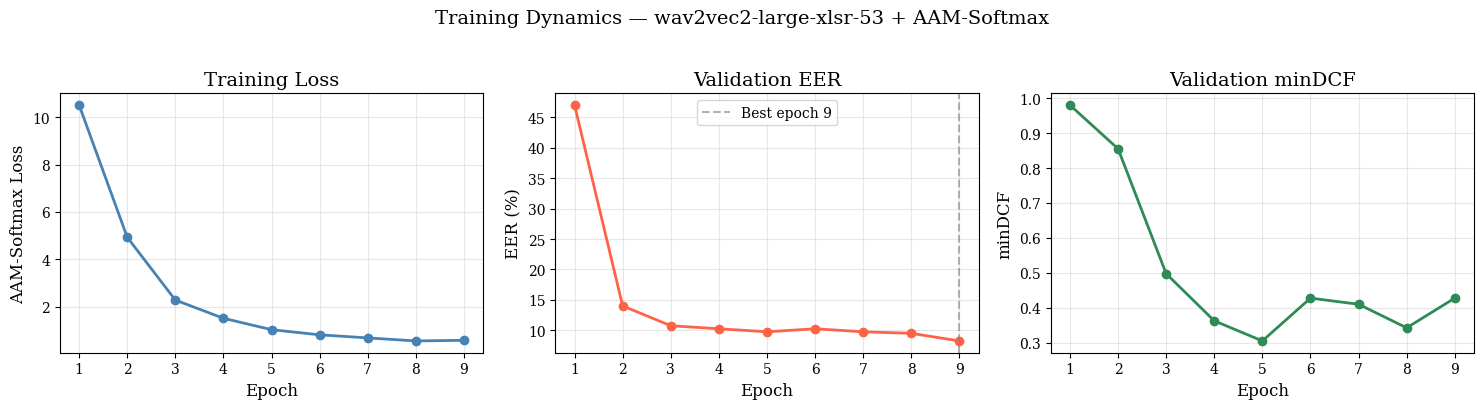

Saved: fig_training_curves.png


In [12]:
# ── CELL 12: Training curves ──────────────────────────────────
epochs   = [e['epoch']      for e in epoch_log]
losses   = [e['loss']       for e in epoch_log]
val_eers = [e['val_eer']    for e in epoch_log]
val_dcfs = [e['val_mindcf'] for e in epoch_log]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs, losses, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AAM-Softmax Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Val EER
best_eer_epoch = epochs[int(np.argmin(val_eers))]
axes[1].plot(epochs, val_eers, 'o-', color='tomato', linewidth=2, markersize=6)
axes[1].axvline(best_eer_epoch, color='gray', linestyle='--', alpha=0.6,
                label=f'Best epoch {best_eer_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('EER (%)')
axes[1].set_title('Validation EER')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val minDCF
axes[2].plot(epochs, val_dcfs, 'o-', color='seagreen', linewidth=2, markersize=6)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('minDCF')
axes[2].set_title('Validation minDCF')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Dynamics — wav2vec2-large-xlsr-53 + AAM-Softmax', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('fig_training_curves.png')
plt.show()
print('Saved: fig_training_curves.png')

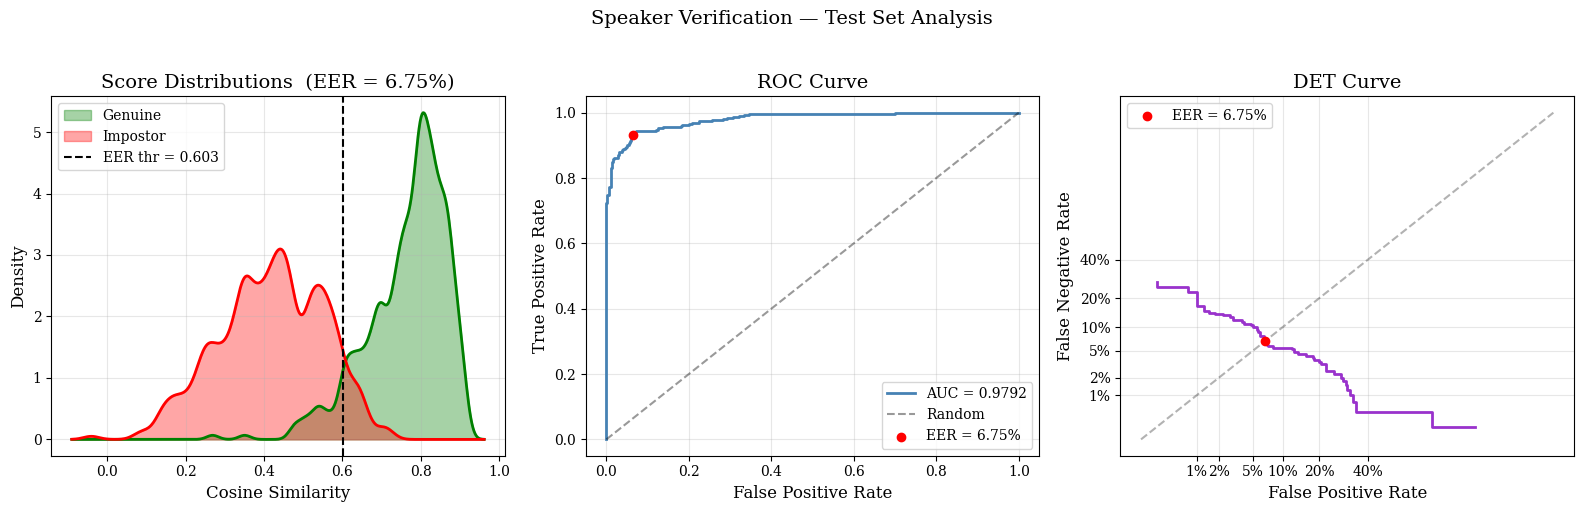

Saved: fig_score_roc_det.png


In [13]:
# ── CELL 13: Score distribution + ROC + DET curves ────────────
from scipy.stats import gaussian_kde
from sklearn.metrics import auc as sklearn_auc

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Score distribution ──
x = np.linspace(test_scores.min() - 0.05, test_scores.max() + 0.05, 400)
kde_gen = gaussian_kde(genuine_scores,  bw_method=0.15)
kde_imp = gaussian_kde(impostor_scores, bw_method=0.15)

axes[0].fill_between(x, kde_gen(x), alpha=0.35, color='green', label='Genuine')
axes[0].fill_between(x, kde_imp(x), alpha=0.35, color='red',   label='Impostor')
axes[0].plot(x, kde_gen(x), 'g-', linewidth=2)
axes[0].plot(x, kde_imp(x), 'r-', linewidth=2)
axes[0].axvline(eer_threshold, color='black', linestyle='--', linewidth=1.5,
                label=f'EER thr = {eer_threshold:.3f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Score Distributions  (EER = {test_eer:.2f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── ROC curve ──
roc_auc_val = sklearn_auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC = {roc_auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1].scatter(fpr[eer_idx], tpr[eer_idx], color='red', zorder=5,
                label=f'EER = {test_eer:.2f}%')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── DET curve (probit scale) ──
mask = (fpr > 1e-4) & (fpr < 1 - 1e-4) & (fnr > 1e-4) & (fnr < 1 - 1e-4)
fpr_nd = scipy_norm.ppf(fpr[mask])
fnr_nd = scipy_norm.ppf(fnr[mask])
axes[2].plot(fpr_nd, fnr_nd, color='darkorchid', linewidth=2)
eer_nd = scipy_norm.ppf(test_eer / 100)
axes[2].scatter([eer_nd], [eer_nd], color='red', zorder=5,
                label=f'EER = {test_eer:.2f}%')
axes[2].plot([-3, 2], [-3, 2], 'k--', alpha=0.3)
ticks_pct = [1, 2, 5, 10, 20, 40]
tick_nd   = [scipy_norm.ppf(t / 100) for t in ticks_pct]
axes[2].set_xticks(tick_nd); axes[2].set_xticklabels([f'{t}%' for t in ticks_pct])
axes[2].set_yticks(tick_nd); axes[2].set_yticklabels([f'{t}%' for t in ticks_pct])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('False Negative Rate')
axes[2].set_title('DET Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Speaker Verification — Test Set Analysis', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('fig_score_roc_det.png')
plt.show()
print('Saved: fig_score_roc_det.png')

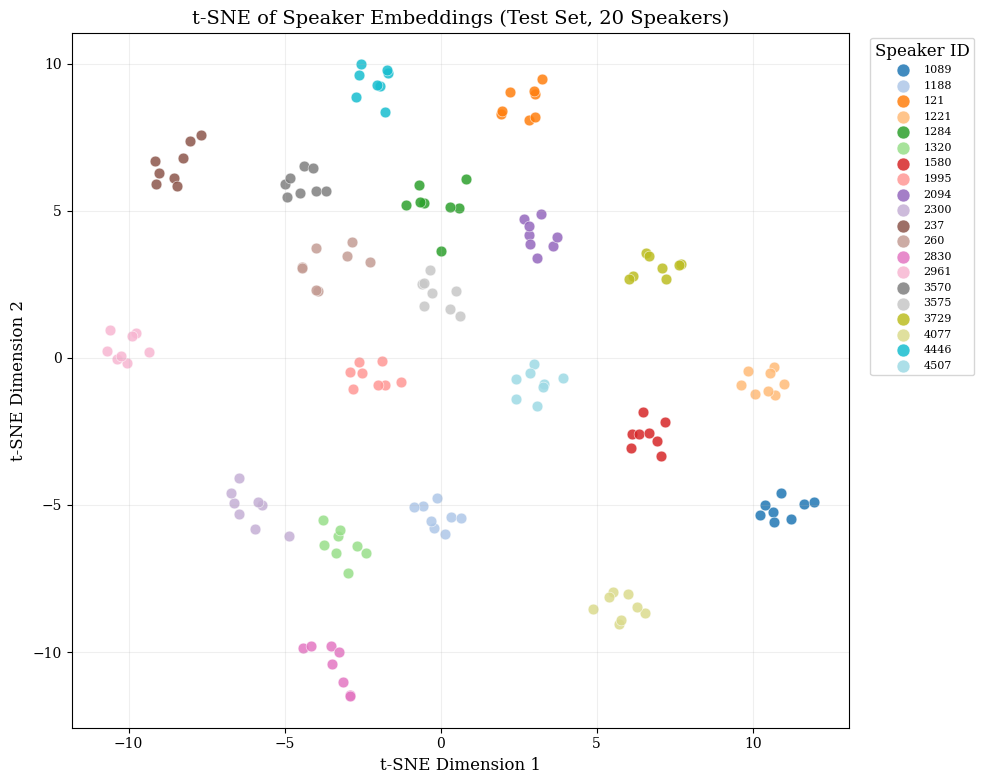

Saved: fig_tsne.png


In [14]:
# ── CELL 14: t-SNE speaker embeddings ─────────────────────────
from sklearn.manifold import TSNE

embs, spk_ids = extract_embeddings(model.encoder, test_items, max_speakers=20, max_utts=8)
unique_spks   = sorted(set(spk_ids))
spk2int       = {s: i for i, s in enumerate(unique_spks)}
color_ids     = np.array([spk2int[s] for s in spk_ids])

tsne    = TSNE(n_components=2, random_state=cfg.seed, perplexity=min(30, len(embs) - 1))
embs_2d = tsne.fit_transform(embs)

cmap   = matplotlib.colormaps.get_cmap('tab20').resampled(len(unique_spks))
fig, ax = plt.subplots(figsize=(10, 8))
for i, spk in enumerate(unique_spks):
    mask = color_ids == i
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
               color=cmap(i), label=spk, s=60, alpha=0.85, edgecolors='white', linewidths=0.4)

ax.legend(title='Speaker ID', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, markerscale=1.2)
ax.set_title('t-SNE of Speaker Embeddings (Test Set, 20 Speakers)', fontsize=14)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig_tsne.png')
plt.show()
print('Saved: fig_tsne.png')

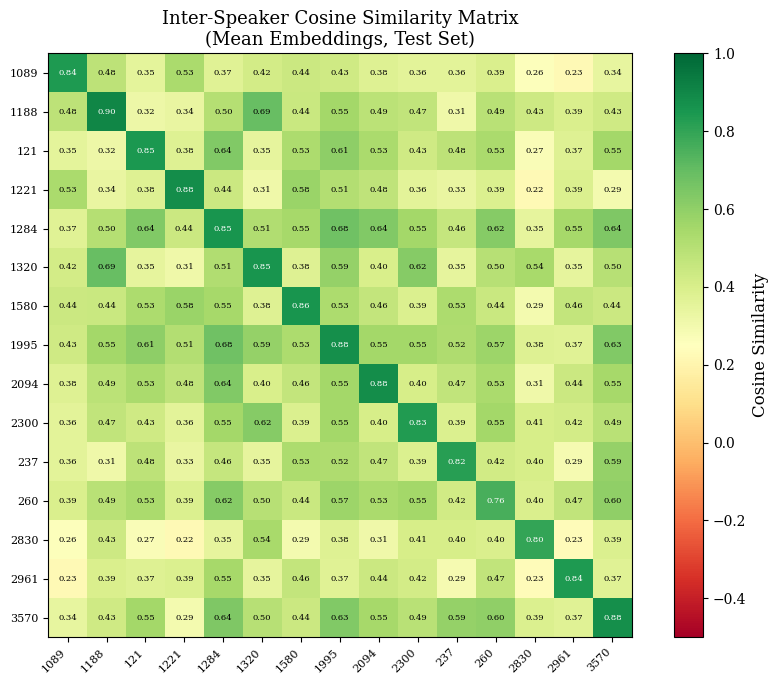

Saved: fig_similarity_matrix.png


In [15]:
# ── CELL 15: Cosine similarity heatmap ────────────────────────
n_spk    = min(15, len(test_items))
test_spks = sorted(test_items.keys())[:n_spk]

mean_embs = torch.cat([
    mean_speaker_embedding(model.encoder, test_items[s]) for s in test_spks
])  # [n_spk, emb_dim]

sim_matrix = (mean_embs @ mean_embs.T).numpy()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-0.5, vmax=1.0)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(n_spk)); ax.set_xticklabels(test_spks, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n_spk)); ax.set_yticklabels(test_spks, fontsize=8)
for i in range(n_spk):
    for j in range(n_spk):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=6, color='black' if abs(sim_matrix[i, j]) < 0.7 else 'white')
ax.set_title('Inter-Speaker Cosine Similarity Matrix\n(Mean Embeddings, Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_similarity_matrix.png')
plt.show()
print('Saved: fig_similarity_matrix.png')